In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "CalisanID": range(1, 21),
    "Isim": ["Ali","Ayşe","Mehmet","Zeynep","Ahmet","Elif","Burak","Gamze","Can","Merve",
             "Yusuf","Deniz","Hakan","Selin","Fatih","Derya","Kerem","Esra","Onur","Melis"],
    "Departman": ["IT","Muhasebe","IT","IK","IK","IT","Pazarlama","IT","Muhasebe","Pazarlama",
                  "IK","IT","Muhasebe","Pazarlama","IT","IK","IT","Muhasebe","Pazarlama","IK"],
    "Maas": np.random.randint(4000,12000,20),
    "Yas": np.random.randint(22,50,20)
}

In [4]:
df = pd.DataFrame(data)

In [5]:
df

,CalisanID,Isim,Departman,Maas,Yas
0,1,Ali,IT,6238,39
1,2,Ayşe,Muhasebe,5032,44
2,3,Mehmet,IT,5774,46
3,4,Zeynep,IK,10627,40
4,5,Ahmet,IK,4128,49
5,6,Elif,IT,9420,35
6,7,Burak,Pazarlama,4665,40
7,8,Gamze,IT,7278,27
8,9,Can,Muhasebe,6283,47
9,10,Merve,Pazarlama,10866,38


In [8]:
df["Departman"].unique()

array(['IT', 'Muhasebe', 'IK', 'Pazarlama'], dtype=object)

In [9]:
df["Departman"].nunique()

4

In [11]:
df["Maas"].mean()

np.float64(7719.9)

In [26]:
df[df["Yas"] == df["Yas"].min()]

,CalisanID,Isim,Departman,Maas,Yas
18,19,Onur,Pazarlama,6463,24


In [29]:
df.loc[df["Yas"].idxmin(),["Isim","Departman"]].to_frame().T

,Isim,Departman
18,Onur,Pazarlama


In [30]:
df.query("Yas == Yas.min()")

,CalisanID,Isim,Departman,Maas,Yas
18,19,Onur,Pazarlama,6463,24


In [31]:
departmanGr = df.groupby("Departman")

In [35]:
departmanGr["Maas"].mean()

Departman
IK           8497.200000
IT           7452.714286
Muhasebe     7411.500000
Pazarlama    7524.250000
Name: Maas, dtype: float64

In [36]:
departmanGr["Yas"].mean()

Departman
IK           38.600000
IT           39.142857
Muhasebe     38.000000
Pazarlama    37.500000
Name: Yas, dtype: float64

In [52]:
print((df["Yas"]> 30).sum())

16


In [45]:
df.loc[df["Maas"] > 8000,["Isim","Departman"]]

,Isim,Departman
3,Zeynep,IK
5,Elif,IT
9,Merve,Pazarlama
10,Yusuf,IK
12,Hakan,Muhasebe
13,Selin,Pazarlama
16,Kerem,IT
17,Esra,Muhasebe
19,Melis,IK


In [47]:
departmanGr[["Maas","Yas"]].mean()

,Maas,Yas
Departman,,
IK,8497.200000,38.600000
IT,7452.714286,39.142857
Muhasebe,7411.500000,38.000000
Pazarlama,7524.250000,37.500000


In [56]:
departmanGr["Maas"].sum()

Departman
IK           42486
IT           52169
Muhasebe     29646
Pazarlama    30097
Name: Maas, dtype: int32

<BarContainer object of 4 artists>

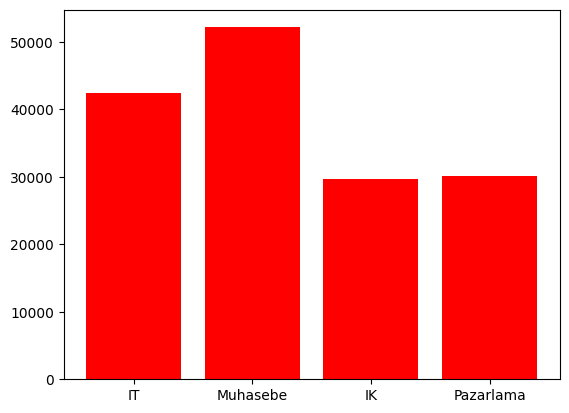

In [67]:
MaasTop = np.array(departmanGr["Maas"].sum())
DepartmanIsim = np.array(df["Departman"].unique())
plt.bar(DepartmanIsim,MaasTop,color = "Red")   #eşleşmeler yanlıs

Text(0.5, 1.0, 'Departmanlara Göre Toplam Maaş Grafigi')

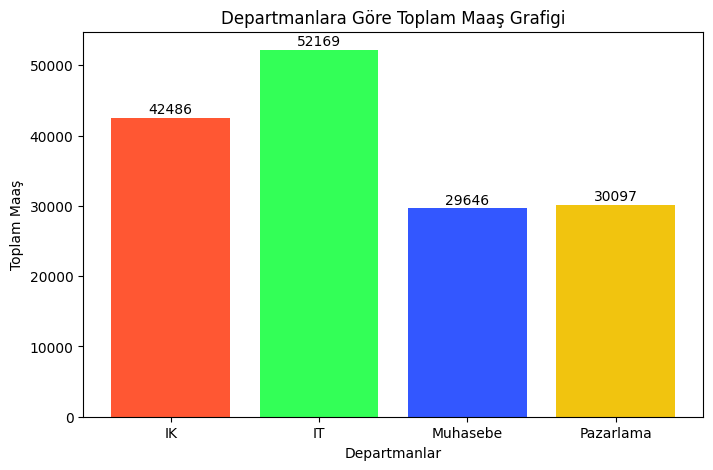

In [78]:
maasTop = departmanGr["Maas"].sum()
plt.figure(figsize=(8,5))
bars = plt.bar(maasTop.index, maasTop,color=['#FF5733','#33FF57','#3357FF','#F1C40F'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200, f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.ylabel("Toplam Maaş")
plt.xlabel("Departmanlar")
plt.title("Departmanlara Göre Toplam Maaş Grafigi")

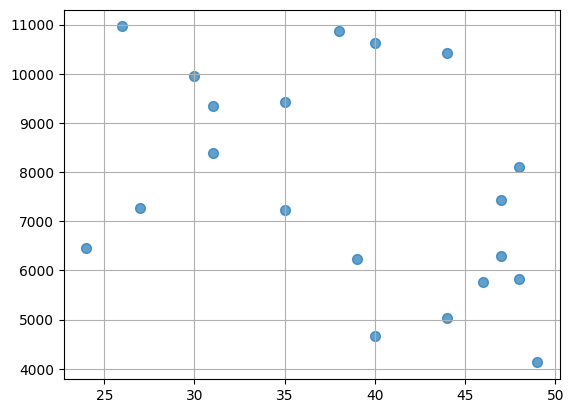

In [89]:
maaslar = np.array(df["Maas"])
yaslar = np.array(df["Yas"])

plt.scatter(yaslar,maaslar,s=50, alpha=0.7)
plt.grid(True)  # çizgileri ekler

In [96]:
df

,CalisanID,Isim,Departman,Maas,Yas
0,1,Ali,IT,6238,39
1,2,Ayşe,Muhasebe,5032,44
2,3,Mehmet,IT,5774,46
3,4,Zeynep,IK,10627,40
4,5,Ahmet,IK,4128,49
5,6,Elif,IT,9420,35
6,7,Burak,Pazarlama,4665,40
7,8,Gamze,IT,7278,27
8,9,Can,Muhasebe,6283,47
9,10,Merve,Pazarlama,10866,38


In [102]:
df.groupby("Departman")["Isim"].count()

Departman
IK           5
IT           7
Muhasebe     4
Pazarlama    4
Name: Isim, dtype: int64

In [110]:
besyılaraYas = pd.cut(df["Yas"], bins=range(20,65,5))    # her yaş aralıgını 5 fark olan 20-25 gibi gruplara ayırır ve alt satırda bu grupların ort bulur
print(besyılaraYas)

0     (35, 40]
1     (40, 45]
2     (45, 50]
3     (35, 40]
4     (45, 50]
5     (30, 35]
6     (35, 40]
7     (25, 30]
8     (45, 50]
9     (35, 40]
10    (25, 30]
11    (45, 50]
12    (30, 35]
13    (45, 50]
14    (30, 35]
15    (45, 50]
16    (40, 45]
17    (25, 30]
18    (20, 25]
19    (30, 35]
Name: Yas, dtype: category
Categories (8, interval[int64, right]): [(20, 25] < (25, 30] < (30, 35] < (35, 40] < (40, 45] < (45, 50] < (50, 55] < (55, 60]]


In [109]:
df.groupby(besyılaraYas)["Maas"].mean().reset_index()

C:\Users\kursa\AppData\Local\Temp\ipykernel_12380\71875074.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(besyılaraYas)["Maas"].mean().reset_index()


,Yas,Maas
0,"(20, 25]",6463.000000
1,"(25, 30]",9395.000000
2,"(30, 35]",8589.500000
3,"(35, 40]",8099.000000
4,"(40, 45]",7728.000000
5,"(45, 50]",6256.666667
6,"(50, 55]",NaN
7,"(55, 60]",NaN


In [120]:
binSay= [0,5000,9000,np.inf]
labelSay = ["Düşük","Orta","Yüksek"]

In [121]:
df["MaasKategori"] = pd.cut(df["Maas"], bins=binSay, labels=labelSay)

In [129]:
kategoriSay = df["MaasKategori"].value_counts().sort_index()

In [128]:
kategoriSay

MaasKategori
Orta      11
Yüksek     7
Düşük      2
Name: count, dtype: int64